In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Grapevine_Trunk_Diseases_detection',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)


val_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Grapevine_Trunk_Diseases_detection',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 1411 images belonging to 2 classes.
Found 351 images belonging to 2 classes.


In [ ]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,107,265 (19.48 MB)

 Trainable params: 5,107,265 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


model.fit(train_generator, epochs=5, validation_data=val_generator, batch_size=BATCH_SIZE)


model.save('/content/drive/MyDrive/Grapevine_Trunk_Diseases_detection/vinefungidetector.h5')

Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 1090s 24s/step - accuracy: 0.8661 - loss: 0.3727 - val_accuracy: 0.8803 - val_loss: 0.4889
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 177ms/step - accuracy: 0.9433 - loss: 0.2107 - val_accuracy: 0.9003 - val_loss: 0.3421
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 183ms/step - accuracy: 0.9426 - loss: 0.1503 - val_accuracy: 0.9003 - val_loss: 0.3427
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.9518 - loss: 0.1517 - val_accuracy: 0.8974 - val_loss: 0.3745
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 184ms/step - accuracy: 0.9511 - loss: 0.1453 - val_accuracy: 0.9031 - val_loss: 0.3175


Model Loaded


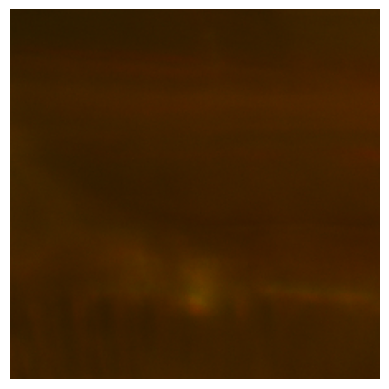

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 792ms/step
[[0.6117156]]
Fungal pathogen detected in the vine wood.


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np


model = load_model('/content/drive/MyDrive/Grapevine_Trunk_Diseases_detection/vinefungidetector.h5')
print("Model Loaded")


test_image_path = "/content/63.tif"
img = image.load_img(test_image_path, target_size=(IMG_SIZE, IMG_SIZE))
plt.imshow(img)
plt.axis('off')
plt.show()


img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.

prediction = model.predict(img_array)
print(prediction)

if prediction >= 0.5:
    print("Fungal pathogen detected in the vine wood.")
else:
    print("Vine wood sample is healthy.")
